# Experiment: Robust General Diagnosis

Goal:
- Diagnose one or two runs using a single config-driven notebook.
- Support both train and evaluation artifacts across `runs/2026/2`.
- Keep plotting robust when schemas vary; panels with missing data show explicit placeholders.

Expected outputs (with automatic availability checks):
1. Resolved source summary table (run path, chosen log type, file path).
2. Information plan table: which plots/tables are available per run.
3. Core diagnosis plots:
   - Rubric/Reward Trend
   - Validity vs Format
   - Length Dynamics
   - SDPO Selection Dynamics
   - Top Drop Reasons by Batch
   - Group Diagnostics
4. Phase summary table (early/middle/late) for key metrics.


In [8]:
# Setup
from __future__ import annotations

from collections import Counter
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    pass

pd.set_option('display.max_columns', 260)
pd.set_option('display.width', 280)


In [9]:
# Config
# Put one or two paths here. Each path can be a run directory or a direct *.jsonl file.
LOG_PATHS = [
    Path("/home/silas/co-scientist-project/runs/2026/2/withA1,A2/2(ml)"),
     Path("/home/silas/co-scientist-project/runs/2026/2/SDPO/28_recovery_A_warmstart_best214"),
]

# Evaluation mode: if True, prefer evaluation artifacts; fallback to train depends on flag below.
EXAMINE_EVALUATION = True
EVAL_FILE_POLICY = 'latest'  # 'latest' | 'earliest'
FALLBACK_TO_TRAIN_IF_NO_EVAL = True

# Auto-pick from runs root only when LOG_PATHS is empty.
RUNS_ROOT = Path('/home/silas/co-scientist-project/runs/2026/2')
AUTO_PICK_IF_LOG_PATHS_EMPTY = False
AUTO_PICK_COUNT = 1  # 1 or 2
AUTO_PICK_METHOD_HINT = None  # e.g. 'SDPO'

# Plot controls
SMOOTH_WINDOW = 5
TOP_DROP_PLOTS = 6
MAX_ROWS_PER_FILE = None  # set int for faster debug


In [10]:
# Helpers: source resolution, normalization, and plotting
TRAIN_BATCH_REL = ['train/batch_summary.jsonl', 'batch_summary.jsonl']
TRAIN_LOG_REL = ['train/training_logs.jsonl', 'training_logs.jsonl']


def read_jsonl(path: Path, max_rows: int | None = None) -> list[dict]:
    if path is None or (not path.exists()) or (not path.is_file()):
        return []
    rows = []
    with path.open('r', encoding='utf-8', errors='ignore') as f:
        for i, line in enumerate(f, start=1):
            if max_rows is not None and i > max_rows:
                break
            s = line.strip()
            if not s:
                continue
            try:
                rows.append(json.loads(s))
            except json.JSONDecodeError:
                continue
    return rows


def _first_existing(base: Path, rels: list[str]) -> Path | None:
    for rel in rels:
        p = base / rel
        if p.exists() and p.is_file():
            return p
    return None


def _extract_step_from_eval_name(path: Path, stem_prefix: str) -> int | None:
    m = re.search(rf'{re.escape(stem_prefix)}\(([-]?\d+)\)\.jsonl$', path.name)
    if not m:
        return None
    try:
        return int(m.group(1))
    except Exception:
        return None


def _choose_eval_file(eval_dir: Path, base_name: str, policy: str) -> Path | None:
    files = sorted([p for p in eval_dir.glob(f'{base_name}*.jsonl') if p.is_file()])
    if not files:
        return None

    policy = str(policy).strip().lower()
    if policy not in {'latest', 'earliest'}:
        policy = 'latest'

    ranked = []
    for p in files:
        step = _extract_step_from_eval_name(p, base_name)
        ranked.append((p, step if step is not None else -10**9, p.stat().st_mtime))

    if policy == 'earliest':
        ranked.sort(key=lambda x: (x[1], x[2]))
    else:
        ranked.sort(key=lambda x: (x[1], x[2]), reverse=True)
    return ranked[0][0]


def infer_kind_from_file(path: Path) -> str:
    n = path.name
    if 'eval_batch_summary' in n:
        return 'eval_batch_summary'
    if 'eval_logs' in n:
        return 'eval_logs'
    if 'batch_summary' in n:
        return 'train_batch_summary'
    if 'training_logs' in n:
        return 'train_logs'
    return 'jsonl'


def discover_run_dirs(root: Path, method_hint: str | None = None) -> list[Path]:
    if not root.exists():
        return []

    found = {}
    for rel in TRAIN_LOG_REL:
        for p in root.rglob(rel):
            if not p.is_file():
                continue
            rd = p.parent.parent if p.parent.name == 'train' else p.parent
            if method_hint and method_hint.lower() not in str(rd).lower():
                continue
            found[str(rd.resolve())] = rd.resolve()

    out = list(found.values())
    out.sort()
    return out


def resolve_source_for_path(path_like: Path):
    p = Path(path_like)
    if p.is_file():
        rd = p.parent.parent if p.parent.name == 'train' else p.parent
        return {
            'run_dir': rd.resolve(),
            'source_path': p.resolve(),
            'source_kind': infer_kind_from_file(p),
            'mode': 'direct_file',
        }

    rd = p.resolve()
    if not rd.exists() or not rd.is_dir():
        return {
            'run_dir': rd,
            'source_path': None,
            'source_kind': 'missing',
            'mode': 'missing',
        }

    if EXAMINE_EVALUATION:
        eval_dir = rd / 'evaluation'
        if eval_dir.exists() and eval_dir.is_dir():
            p_eval_batch = _choose_eval_file(eval_dir, 'eval_batch_summary', EVAL_FILE_POLICY)
            if p_eval_batch is not None:
                return {
                    'run_dir': rd,
                    'source_path': p_eval_batch,
                    'source_kind': 'eval_batch_summary',
                    'mode': 'evaluation',
                }

            p_eval_logs = _choose_eval_file(eval_dir, 'eval_logs', EVAL_FILE_POLICY)
            if p_eval_logs is not None:
                return {
                    'run_dir': rd,
                    'source_path': p_eval_logs,
                    'source_kind': 'eval_logs',
                    'mode': 'evaluation',
                }

        if not FALLBACK_TO_TRAIN_IF_NO_EVAL:
            return {
                'run_dir': rd,
                'source_path': None,
                'source_kind': 'evaluation_missing',
                'mode': 'evaluation',
            }

    p_train_batch = _first_existing(rd, TRAIN_BATCH_REL)
    if p_train_batch is not None:
        return {
            'run_dir': rd,
            'source_path': p_train_batch,
            'source_kind': 'train_batch_summary',
            'mode': 'train',
        }

    p_train_log = _first_existing(rd, TRAIN_LOG_REL)
    if p_train_log is not None:
        return {
            'run_dir': rd,
            'source_path': p_train_log,
            'source_kind': 'train_logs',
            'mode': 'train',
        }

    return {
        'run_dir': rd,
        'source_path': None,
        'source_kind': 'missing',
        'mode': 'train',
    }


def resolve_inputs() -> list[dict]:
    given = [Path(x) for x in LOG_PATHS]

    if len(given) > 2:
        raise ValueError('LOG_PATHS supports at most 2 paths.')

    if given:
        out = [resolve_source_for_path(p) for p in given]
        return out

    if not AUTO_PICK_IF_LOG_PATHS_EMPTY:
        raise ValueError('LOG_PATHS is empty and AUTO_PICK_IF_LOG_PATHS_EMPTY is False.')

    count = int(AUTO_PICK_COUNT)
    if count not in (1, 2):
        raise ValueError('AUTO_PICK_COUNT must be 1 or 2.')

    run_dirs = discover_run_dirs(RUNS_ROOT, AUTO_PICK_METHOD_HINT)
    resolved = []
    for rd in run_dirs:
        info = resolve_source_for_path(rd)
        sp = info['source_path']
        if sp is None or not sp.exists():
            continue
        info['_mtime'] = sp.stat().st_mtime
        resolved.append(info)

    if not resolved:
        return []

    resolved.sort(key=lambda x: x['_mtime'], reverse=True)
    picked = resolved[:count]
    for p in picked:
        p.pop('_mtime', None)
    return picked


def pick_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None


def to_numeric_series(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors='coerce')


def smooth(s: pd.Series, w: int) -> pd.Series:
    if s is None or int(w) <= 1:
        return s
    return s.rolling(window=int(w), min_periods=1).mean()


def _ensure_batch_idx(df: pd.DataFrame) -> pd.Series:
    c = pick_col(df, ['batch_idx', 'progress/batch', 'step', 'global_step'])
    if c is None:
        return pd.Series(np.arange(len(df), dtype=int), index=df.index)

    v = to_numeric_series(df[c])
    fallback = pd.Series(np.arange(len(df), dtype=int), index=df.index)
    v = v.where(~v.isna(), fallback)
    return v.astype(int)


def normalize_from_batch_rows(rows: list[dict]) -> tuple[pd.DataFrame, list[str]]:
    if not rows:
        return pd.DataFrame(), []

    raw = pd.DataFrame(rows)
    raw = raw.copy()
    raw['batch_idx'] = _ensure_batch_idx(raw)

    alias = {
        'rubric_valid': ['rubric/sample_mean_valid', 'rubric/sample_mean_all', 'rubric/total_valid'],
        'reward_valid': ['reward/sample_mean_valid', 'reward/total', 'reward/group_mean_valid'],
        'samples_generated': ['samples/generated', 'samples/total', 'samples/collected'],
        'samples_valid': ['samples/valid', 'samples/trainability_pass'],
        'valid_rate': ['samples/trainability_pass_rate', 'valid_rate'],
        'format_rate': ['format_rate', 'format/penalty_mean'],
        'len_solution': ['length_mean', 'length/solution_mean'],
        'len_total': ['length/total_mean', 'length_total_mean'],
        'len_think': ['length/think_mean'],
        'sdpo_cutoff': ['sdpo/success_cutoff'],
        'sdpo_success_rate': ['sdpo/success_rate_groups'],
        'groups_used': ['groups/used_for_training'],
        'groups_skip_no_rewards': ['groups/skipped_no_rewards'],
        'groups_skip_zero_adv': ['groups/skipped_zero_adv'],
    }

    norm = pd.DataFrame({'batch_idx': raw['batch_idx']})
    for k, cands in alias.items():
        c = pick_col(raw, cands)
        norm[k] = to_numeric_series(raw[c]) if c else np.nan

    if norm['valid_rate'].isna().all() and (not norm['samples_generated'].isna().all()) and (not norm['samples_valid'].isna().all()):
        g = norm['samples_generated']
        v = norm['samples_valid']
        norm['valid_rate'] = np.where(g > 0, v / g, np.nan)

    if norm['len_total'].isna().all() and (not norm['len_solution'].isna().all()) and (not norm['len_think'].isna().all()):
        norm['len_total'] = norm['len_solution'] + norm['len_think']

    drop_cols = [c for c in raw.columns if isinstance(c, str) and c.startswith('drops/')]
    for c in drop_cols:
        norm[c] = to_numeric_series(raw[c]).fillna(0.0)

    norm = norm.sort_values('batch_idx').reset_index(drop=True)
    return norm, drop_cols


def _sanitize_reason(reason: str) -> str:
    s = str(reason).strip().lower()
    s = re.sub(r'[^a-z0-9_\-]+', '_', s)
    s = re.sub(r'_+', '_', s).strip('_')
    return s or 'unknown'


def normalize_from_sample_rows(rows: list[dict]) -> tuple[pd.DataFrame, list[str]]:
    if not rows:
        return pd.DataFrame(), []

    raw = pd.DataFrame(rows)
    raw = raw.copy()
    raw['batch_idx'] = _ensure_batch_idx(raw)

    grp = raw.groupby('batch_idx', as_index=False)
    norm = pd.DataFrame({'batch_idx': sorted(raw['batch_idx'].unique())})

    def grouped_mean(col: str):
        if col not in raw.columns:
            return pd.Series(np.nan, index=norm.index)
        tmp = grp[col].mean(numeric_only=False)
        return to_numeric_series(tmp[col]).reindex(range(len(norm))).reset_index(drop=True)

    rubric_col = pick_col(raw, ['rubric_score'])
    reward_col = pick_col(raw, ['final_reward', 'reward'])

    if rubric_col:
        norm['rubric_valid'] = to_numeric_series(grp[rubric_col].mean(numeric_only=False)[rubric_col])
    else:
        norm['rubric_valid'] = np.nan

    if reward_col:
        norm['reward_valid'] = to_numeric_series(grp[reward_col].mean(numeric_only=False)[reward_col])
    else:
        norm['reward_valid'] = np.nan

    if 'is_trainable' in raw.columns:
        tmp = raw['is_trainable'].astype(float)
        norm['valid_rate'] = raw.assign(_v=tmp).groupby('batch_idx')['_v'].mean().reset_index(drop=True)
    elif 'status' in raw.columns:
        tmp = raw['status'].astype(str).str.lower().eq('valid').astype(float)
        norm['valid_rate'] = raw.assign(_v=tmp).groupby('batch_idx')['_v'].mean().reset_index(drop=True)
    elif 'is_compliant' in raw.columns:
        tmp = raw['is_compliant'].astype(float)
        norm['valid_rate'] = raw.assign(_v=tmp).groupby('batch_idx')['_v'].mean().reset_index(drop=True)
    else:
        norm['valid_rate'] = np.nan

    if 'format_penalty' in raw.columns:
        fp = to_numeric_series(raw['format_penalty']).fillna(0.0)
        tmp = (fp > 1e-12).astype(float)
        norm['format_rate'] = raw.assign(_f=tmp).groupby('batch_idx')['_f'].mean().reset_index(drop=True)
    elif 'is_compliant' in raw.columns:
        tmp = (~raw['is_compliant'].astype(bool)).astype(float)
        norm['format_rate'] = raw.assign(_f=tmp).groupby('batch_idx')['_f'].mean().reset_index(drop=True)
    else:
        norm['format_rate'] = np.nan

    sol_col = pick_col(raw, ['word_count_solution', 'word_count'])
    total_col = pick_col(raw, ['word_count_total', 'word_count'])
    think_col = pick_col(raw, ['think_word_count'])

    if sol_col:
        norm['len_solution'] = to_numeric_series(grp[sol_col].mean(numeric_only=False)[sol_col])
    else:
        norm['len_solution'] = np.nan
    if total_col:
        norm['len_total'] = to_numeric_series(grp[total_col].mean(numeric_only=False)[total_col])
    else:
        norm['len_total'] = np.nan
    if think_col:
        norm['len_think'] = to_numeric_series(grp[think_col].mean(numeric_only=False)[think_col])
    else:
        norm['len_think'] = np.nan

    if norm['len_total'].isna().all() and (not norm['len_solution'].isna().all()) and (not norm['len_think'].isna().all()):
        norm['len_total'] = norm['len_solution'] + norm['len_think']

    # SDPO + group fields rarely appear in sample logs; keep placeholders.
    norm['sdpo_cutoff'] = np.nan
    norm['sdpo_success_rate'] = np.nan
    norm['groups_used'] = np.nan
    norm['groups_skip_no_rewards'] = np.nan
    norm['groups_skip_zero_adv'] = np.nan

    # Optional groups_used approximation from sample logs
    if 'group_idx' in raw.columns:
        if 'is_trainable' in raw.columns:
            usable = raw[raw['is_trainable'].astype(bool)].copy()
        elif 'status' in raw.columns:
            usable = raw[raw['status'].astype(str).str.lower().eq('valid')].copy()
        else:
            usable = raw.copy()

        if not usable.empty:
            gu = usable.groupby('batch_idx')['group_idx'].nunique().astype(float).reset_index(drop=True)
            norm['groups_used'] = gu

    drop_cols = []
    if 'drop_reason' in raw.columns:
        dr = raw[['batch_idx', 'drop_reason']].copy()
        dr['drop_reason'] = dr['drop_reason'].fillna('unknown').astype(str)
        pivot = dr.pivot_table(index='batch_idx', columns='drop_reason', aggfunc='size', fill_value=0)
        pivot = pivot.sort_index().reset_index()
        for reason in pivot.columns:
            if reason == 'batch_idx':
                continue
            safe = _sanitize_reason(reason)
            cname = f'drops/{safe}'
            norm = norm.merge(pivot[['batch_idx', reason]].rename(columns={reason: cname}), on='batch_idx', how='left')
            norm[cname] = to_numeric_series(norm[cname]).fillna(0.0)
            drop_cols.append(cname)

    norm = norm.sort_values('batch_idx').reset_index(drop=True)
    return norm, drop_cols


def normalize_rows(rows: list[dict], source_kind: str) -> tuple[pd.DataFrame, list[str]]:
    if source_kind in {'train_batch_summary', 'eval_batch_summary'}:
        return normalize_from_batch_rows(rows)
    return normalize_from_sample_rows(rows)


def has_data(s: pd.Series) -> bool:
    if s is None:
        return False
    return (not s.dropna().empty)


def panel_no_data(ax, title: str, message: str = 'No data for this plot'):
    ax.text(0.5, 0.5, message, ha='center', va='center', transform=ax.transAxes, fontsize=11)
    ax.set_title(title)


def maybe_legend(ax, fontsize=9, loc='best'):
    h, l = ax.get_legend_handles_labels()
    if h:
        ax.legend(fontsize=fontsize, loc=loc)


def plot_single_dashboard(payload: dict):
    norm = payload['norm']
    x = norm['batch_idx']
    drop_cols = payload['drop_cols']

    CB = {
        'blue': '#0057FF',
        'cyan': '#00B8D9',
        'teal': '#00A676',
        'purple': '#7B1FA2',
        'magenta': '#FF1493',
        'navy': '#0B1F5E',
        'red': '#D81B60',
        'black': '#111111',
    }
    LINESTYLES = ['-', '--', '-.', ':']
    DROP_COLOR_CYCLE = [CB['blue'], CB['magenta'], CB['cyan'], CB['purple'], CB['black'], CB['teal'], CB['red'], CB['navy']]

    fig, axes = plt.subplots(3, 2, figsize=(20, 15), sharex=True)

    # Panel 1: rubric + reward
    p = axes[0, 0]
    any_line = False
    if has_data(norm['rubric_valid']):
        p.plot(x, norm['rubric_valid'], label='Rubric (valid mean)', linewidth=2.1, alpha=0.8, color=CB['cyan'], linestyle='-')
        p.plot(x, smooth(norm['rubric_valid'], SMOOTH_WINDOW), label=f'Rubric MA({SMOOTH_WINDOW})', linewidth=2.9, color=CB['blue'], linestyle='-')
        any_line = True
    if has_data(norm['reward_valid']):
        p.plot(x, norm['reward_valid'], label='Reward (valid mean)', linewidth=2.3, alpha=0.95, color=CB['magenta'], linestyle='--')
        any_line = True
    if not any_line:
        panel_no_data(p, 'Rubric/Reward Trend')
    else:
        p.set_title('Rubric/Reward Trend')
        p.set_ylabel('score')
        maybe_legend(p, fontsize=10)

    # Panel 2: validity + format
    p = axes[0, 1]
    any_line = False
    if has_data(norm['valid_rate']):
        p.plot(x, norm['valid_rate'], label='Valid rate', linewidth=2.5, color=CB['teal'], linestyle='-')
        any_line = True
    if has_data(norm['format_rate']):
        p.plot(x, norm['format_rate'], label='Format violation rate', linewidth=2.5, color=CB['navy'], linestyle='--')
        any_line = True
    if not any_line:
        panel_no_data(p, 'Validity vs Format')
    else:
        p.set_title('Validity vs Format')
        p.set_ylabel('rate')
        maybe_legend(p, fontsize=10)

    # Panel 3: lengths
    p = axes[1, 0]
    any_line = False
    if has_data(norm['len_solution']):
        p.plot(x, norm['len_solution'], label='Solution words', linewidth=2.4, color=CB['blue'], linestyle='-')
        any_line = True
    if has_data(norm['len_total']):
        p.plot(x, norm['len_total'], label='Total words', linewidth=2.2, color=CB['black'], linestyle='--')
        any_line = True
    if has_data(norm['len_think']):
        p.plot(x, norm['len_think'], label='Think words', linewidth=2.2, color=CB['magenta'], linestyle='-.')
        any_line = True
    if not any_line:
        panel_no_data(p, 'Length Dynamics')
    else:
        p.set_title('Length Dynamics')
        p.set_ylabel('words')
        maybe_legend(p, fontsize=10)

    # Panel 4: SDPO controls
    p = axes[1, 1]
    any_line = False
    if has_data(norm['sdpo_cutoff']):
        p.plot(x, norm['sdpo_cutoff'], label='SDPO success cutoff', linewidth=2.4, color=CB['purple'], linestyle='-')
        any_line = True
    if has_data(norm['sdpo_success_rate']):
        p.plot(x, norm['sdpo_success_rate'], label='SDPO success rate', linewidth=2.4, color=CB['cyan'], linestyle='--')
        any_line = True
    if not any_line:
        panel_no_data(p, 'SDPO Selection Dynamics')
    else:
        p.set_title('SDPO Selection Dynamics')
        p.set_ylabel('value')
        maybe_legend(p, fontsize=10)

    # Panel 5: drop reasons
    p = axes[2, 0]
    if drop_cols:
        top_drops = norm[drop_cols].sum().sort_values(ascending=False).head(int(TOP_DROP_PLOTS)).index
        if len(top_drops) > 0:
            for i, c in enumerate(top_drops):
                color = DROP_COLOR_CYCLE[i % len(DROP_COLOR_CYCLE)]
                ls = LINESTYLES[i % len(LINESTYLES)]
                p.plot(x, norm[c], label=c, linewidth=2.1, color=color, linestyle=ls)
            p.set_title('Top Drop Reasons by Batch')
            p.set_ylabel('count per batch')
            maybe_legend(p, fontsize=9)
        else:
            panel_no_data(p, 'Top Drop Reasons by Batch')
    else:
        panel_no_data(p, 'Top Drop Reasons by Batch')

    # Panel 6: group diagnostics
    p = axes[2, 1]
    any_line = False
    for i, (c, label) in enumerate([
        ('groups_used', 'Groups used for training'),
        ('groups_skip_no_rewards', 'Groups skipped: no rewards'),
        ('groups_skip_zero_adv', 'Groups skipped: zero advantage'),
    ]):
        if has_data(norm[c]):
            color = DROP_COLOR_CYCLE[i % len(DROP_COLOR_CYCLE)]
            ls = LINESTYLES[i % len(LINESTYLES)]
            p.plot(x, norm[c], label=label, linewidth=2.1, color=color, linestyle=ls)
            any_line = True
    if not any_line:
        panel_no_data(p, 'Group Diagnostics')
    else:
        p.set_title('Group Diagnostics')
        p.set_ylabel('value')
        maybe_legend(p, fontsize=9)

    for ax in axes.ravel():
        ax.tick_params(axis='both', labelsize=10)
    for ax in axes[-1, :]:
        ax.set_xlabel('batch_idx')

    fig.suptitle(f"General Diagnosis: {payload['label']}", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


def _plot_drop_panel(ax, payload: dict, title_suffix: str = ''):
    norm = payload['norm']
    x = norm['batch_idx']
    drop_cols = payload['drop_cols']
    if not drop_cols:
        panel_no_data(ax, f"Top Drop Reasons{title_suffix}")
        return

    top_drops = norm[drop_cols].sum().sort_values(ascending=False).head(int(TOP_DROP_PLOTS)).index
    if len(top_drops) == 0:
        panel_no_data(ax, f"Top Drop Reasons{title_suffix}")
        return

    for c in top_drops:
        ax.plot(x, norm[c], linewidth=2.0, label=c)
    ax.set_title(f"Top Drop Reasons{title_suffix}")
    ax.set_ylabel('count per batch')
    maybe_legend(ax, fontsize=8)


def _plot_group_panel(ax, payload: dict, title_suffix: str = ''):
    norm = payload['norm']
    x = norm['batch_idx']
    any_line = False
    for c, label in [
        ('groups_used', 'Groups used'),
        ('groups_skip_no_rewards', 'Skip no rewards'),
        ('groups_skip_zero_adv', 'Skip zero adv'),
    ]:
        if has_data(norm[c]):
            ax.plot(x, norm[c], linewidth=2.1, label=label)
            any_line = True
    if not any_line:
        panel_no_data(ax, f"Group Diagnostics{title_suffix}")
        return
    ax.set_title(f"Group Diagnostics{title_suffix}")
    ax.set_ylabel('value')
    maybe_legend(ax, fontsize=9)


def plot_two_run_comparison(payloads: list[dict]):
    # Figure 1: overlay core metrics (2x2)
    fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharex=True)

    styles = ['-', '--']
    labels = [p['label'] for p in payloads]

    # Panel A: rubric/reward
    p = axes[0, 0]
    any_line = False
    for i, pl in enumerate(payloads):
        n = pl['norm']
        x = n['batch_idx']
        ls = styles[i % len(styles)]
        if has_data(n['rubric_valid']):
            p.plot(x, smooth(n['rubric_valid'], SMOOTH_WINDOW), linewidth=2.8, linestyle=ls, label=f"{pl['label']} | Rubric MA")
            any_line = True
        if has_data(n['reward_valid']):
            p.plot(x, n['reward_valid'], linewidth=2.2, linestyle=':', label=f"{pl['label']} | Reward")
            any_line = True
    if not any_line:
        panel_no_data(p, 'Rubric/Reward Trend (Overlay)')
    else:
        p.set_title('Rubric/Reward Trend (Overlay)')
        p.set_ylabel('score')
        maybe_legend(p, fontsize=9)

    # Panel B: validity/format
    p = axes[0, 1]
    any_line = False
    for i, pl in enumerate(payloads):
        n = pl['norm']
        x = n['batch_idx']
        ls = styles[i % len(styles)]
        if has_data(n['valid_rate']):
            p.plot(x, n['valid_rate'], linewidth=2.4, linestyle=ls, label=f"{pl['label']} | Valid")
            any_line = True
        if has_data(n['format_rate']):
            p.plot(x, n['format_rate'], linewidth=2.1, linestyle=':', label=f"{pl['label']} | Format violation")
            any_line = True
    if not any_line:
        panel_no_data(p, 'Validity vs Format (Overlay)')
    else:
        p.set_title('Validity vs Format (Overlay)')
        p.set_ylabel('rate')
        maybe_legend(p, fontsize=9)

    # Panel C: lengths
    p = axes[1, 0]
    any_line = False
    for i, pl in enumerate(payloads):
        n = pl['norm']
        x = n['batch_idx']
        ls = styles[i % len(styles)]
        if has_data(n['len_solution']):
            p.plot(x, n['len_solution'], linewidth=2.3, linestyle=ls, label=f"{pl['label']} | Solution")
            any_line = True
        if has_data(n['len_total']):
            p.plot(x, n['len_total'], linewidth=2.0, linestyle='-.', label=f"{pl['label']} | Total")
            any_line = True
        if has_data(n['len_think']):
            p.plot(x, n['len_think'], linewidth=1.9, linestyle=':', label=f"{pl['label']} | Think")
            any_line = True
    if not any_line:
        panel_no_data(p, 'Length Dynamics (Overlay)')
    else:
        p.set_title('Length Dynamics (Overlay)')
        p.set_ylabel('words')
        maybe_legend(p, fontsize=8)

    # Panel D: SDPO selection
    p = axes[1, 1]
    any_line = False
    for i, pl in enumerate(payloads):
        n = pl['norm']
        x = n['batch_idx']
        ls = styles[i % len(styles)]
        if has_data(n['sdpo_cutoff']):
            p.plot(x, n['sdpo_cutoff'], linewidth=2.2, linestyle=ls, label=f"{pl['label']} | Cutoff")
            any_line = True
        if has_data(n['sdpo_success_rate']):
            p.plot(x, n['sdpo_success_rate'], linewidth=2.2, linestyle=':', label=f"{pl['label']} | Success rate")
            any_line = True
    if not any_line:
        panel_no_data(p, 'SDPO Selection Dynamics (Overlay)')
    else:
        p.set_title('SDPO Selection Dynamics (Overlay)')
        p.set_ylabel('value')
        maybe_legend(p, fontsize=9)

    for ax in axes.ravel():
        ax.tick_params(axis='both', labelsize=10)
    for ax in axes[-1, :]:
        ax.set_xlabel('batch_idx')

    fig.suptitle(f"General Diagnosis Comparison: {labels[0]} vs {labels[1]}", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # Figure 2: drop reasons side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(20, 5.8), sharex=False)
    for i, pl in enumerate(payloads):
        _plot_drop_panel(axes[i], pl, title_suffix=f" ({pl['label']})")
        axes[i].set_xlabel('batch_idx')
        axes[i].tick_params(axis='both', labelsize=10)
    plt.tight_layout()
    plt.show()

    # Figure 3: group diagnostics side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(20, 5.8), sharex=False)
    for i, pl in enumerate(payloads):
        _plot_group_panel(axes[i], pl, title_suffix=f" ({pl['label']})")
        axes[i].set_xlabel('batch_idx')
        axes[i].tick_params(axis='both', labelsize=10)
    plt.tight_layout()
    plt.show()


def phase_summary(norm: pd.DataFrame, run_label: str) -> pd.DataFrame:
    if norm is None or norm.empty:
        return pd.DataFrame()

    key_cols = [
        'rubric_valid', 'reward_valid', 'valid_rate', 'format_rate',
        'len_solution', 'len_total', 'len_think', 'sdpo_cutoff', 'sdpo_success_rate',
    ]

    n = len(norm)
    if n == 0:
        return pd.DataFrame()

    c1 = max(1, n // 3)
    c2 = max(c1 + 1, 2 * n // 3)
    chunks = {
        'early': norm.iloc[:c1],
        'middle': norm.iloc[c1:c2],
        'late': norm.iloc[c2:],
    }

    rows = []
    for phase, sub in chunks.items():
        if sub.empty:
            continue
        rec = {'run_label': run_label, 'phase': phase, 'n_batches': len(sub)}
        for c in key_cols:
            rec[c] = float(sub[c].mean(skipna=True)) if c in sub.columns else np.nan
        rows.append(rec)

    return pd.DataFrame(rows)



In [11]:
# Resolve inputs, load data, normalize per run
resolved = resolve_inputs()
if not resolved:
    raise ValueError('No inputs resolved. Check LOG_PATHS or auto-pick config.')

rows = []
payloads = []

for i, info in enumerate(resolved, start=1):
    rd = info['run_dir']
    sp = info['source_path']
    sk = info['source_kind']

    label = rd.name if rd is not None else f'run_{i}'

    if sp is None or not sp.exists():
        rows.append({
            'label': label,
            'run_dir': str(rd),
            'source_kind': sk,
            'source_path': '',
            'status': 'missing_source',
            'n_rows': 0,
            'n_batches': 0,
            'eval_mean_score': np.nan,
            'eval_mean_reward': np.nan,
        })
        continue

    raw_rows = read_jsonl(sp, max_rows=MAX_ROWS_PER_FILE)
    norm, drop_cols = normalize_rows(raw_rows, sk)

    eval_mean_score = np.nan
    eval_mean_reward = np.nan
    if (str(sk).startswith('eval')) and (not norm.empty):
        if 'rubric_valid' in norm.columns and has_data(norm['rubric_valid']):
            eval_mean_score = float(norm['rubric_valid'].mean(skipna=True))
        elif 'reward_valid' in norm.columns and has_data(norm['reward_valid']):
            eval_mean_score = float(norm['reward_valid'].mean(skipna=True))

        if 'reward_valid' in norm.columns and has_data(norm['reward_valid']):
            eval_mean_reward = float(norm['reward_valid'].mean(skipna=True))

    status = 'ok' if not norm.empty else 'parsed_empty'
    rows.append({
        'label': label,
        'run_dir': str(rd),
        'source_kind': sk,
        'source_path': str(sp),
        'status': status,
        'n_rows': len(raw_rows),
        'n_batches': int(len(norm)),
        'eval_mean_score': eval_mean_score,
        'eval_mean_reward': eval_mean_reward,
    })

    if not norm.empty:
        payloads.append({
            'label': label,
            'run_dir': rd,
            'source_path': sp,
            'source_kind': sk,
            'raw_rows': raw_rows,
            'norm': norm,
            'drop_cols': drop_cols,
        })

resolved_df = pd.DataFrame(rows)
display(resolved_df)

if EXAMINE_EVALUATION:
    eval_view = resolved_df[resolved_df['source_kind'].astype(str).str.startswith('eval')].copy()
    if eval_view.empty:
        print('Evaluation mode is ON, but no evaluation artifact was resolved for the selected path(s).')
    else:
        print('Evaluation mean scores:')
        display(eval_view[['label', 'source_kind', 'eval_mean_score', 'eval_mean_reward']].round(4))

if not payloads:
    raise ValueError('All resolved inputs are missing or empty after parsing.')

if len(payloads) > 2:
    raise ValueError('This notebook supports one or two parsed payloads only.')



,label,run_dir,source_kind,source_path,status,n_rows,n_batches,eval_mean_score,eval_mean_reward
0,2(ml),/home/silas/co-scientist-project/runs/2026/2/w...,eval_batch_summary,/home/silas/co-scientist-project/runs/2026/2/w...,ok,10,10,0.692639,0.749844
1,28_recovery_A_warmstart_best214,/home/silas/co-scientist-project/runs/2026/2/S...,eval_batch_summary,/home/silas/co-scientist-project/runs/2026/2/S...,ok,10,10,0.682266,0.736441


Evaluation mean scores:


,label,source_kind,eval_mean_score,eval_mean_reward
0,2(ml),eval_batch_summary,0.6926,0.7498
1,28_recovery_A_warmstart_best214,eval_batch_summary,0.6823,0.7364


In [12]:
# Information plan: what will be plotted/generated next
plan_rows = []
for pl in payloads:
    n = pl['norm']
    plan_rows.append({
        'run_label': pl['label'],
        'source_kind': pl['source_kind'],
        'Rubric/Reward Trend': bool(has_data(n['rubric_valid']) or has_data(n['reward_valid'])),
        'Validity vs Format': bool(has_data(n['valid_rate']) or has_data(n['format_rate'])),
        'Length Dynamics': bool(has_data(n['len_solution']) or has_data(n['len_total']) or has_data(n['len_think'])),
        'SDPO Selection Dynamics': bool(has_data(n['sdpo_cutoff']) or has_data(n['sdpo_success_rate'])),
        'Top Drop Reasons': bool(len(pl['drop_cols']) > 0),
        'Group Diagnostics': bool(has_data(n['groups_used']) or has_data(n['groups_skip_no_rewards']) or has_data(n['groups_skip_zero_adv'])),
        'Phase Summary': True,
    })

info_plan_df = pd.DataFrame(plan_rows)
print('Information to be generated next:')
display(info_plan_df)



Information to be generated next:


,run_label,source_kind,Rubric/Reward Trend,Validity vs Format,Length Dynamics,SDPO Selection Dynamics,Top Drop Reasons,Group Diagnostics,Phase Summary
0,2(ml),eval_batch_summary,True,True,True,False,False,False,True
1,28_recovery_A_warmstart_best214,eval_batch_summary,True,True,True,False,False,False,True


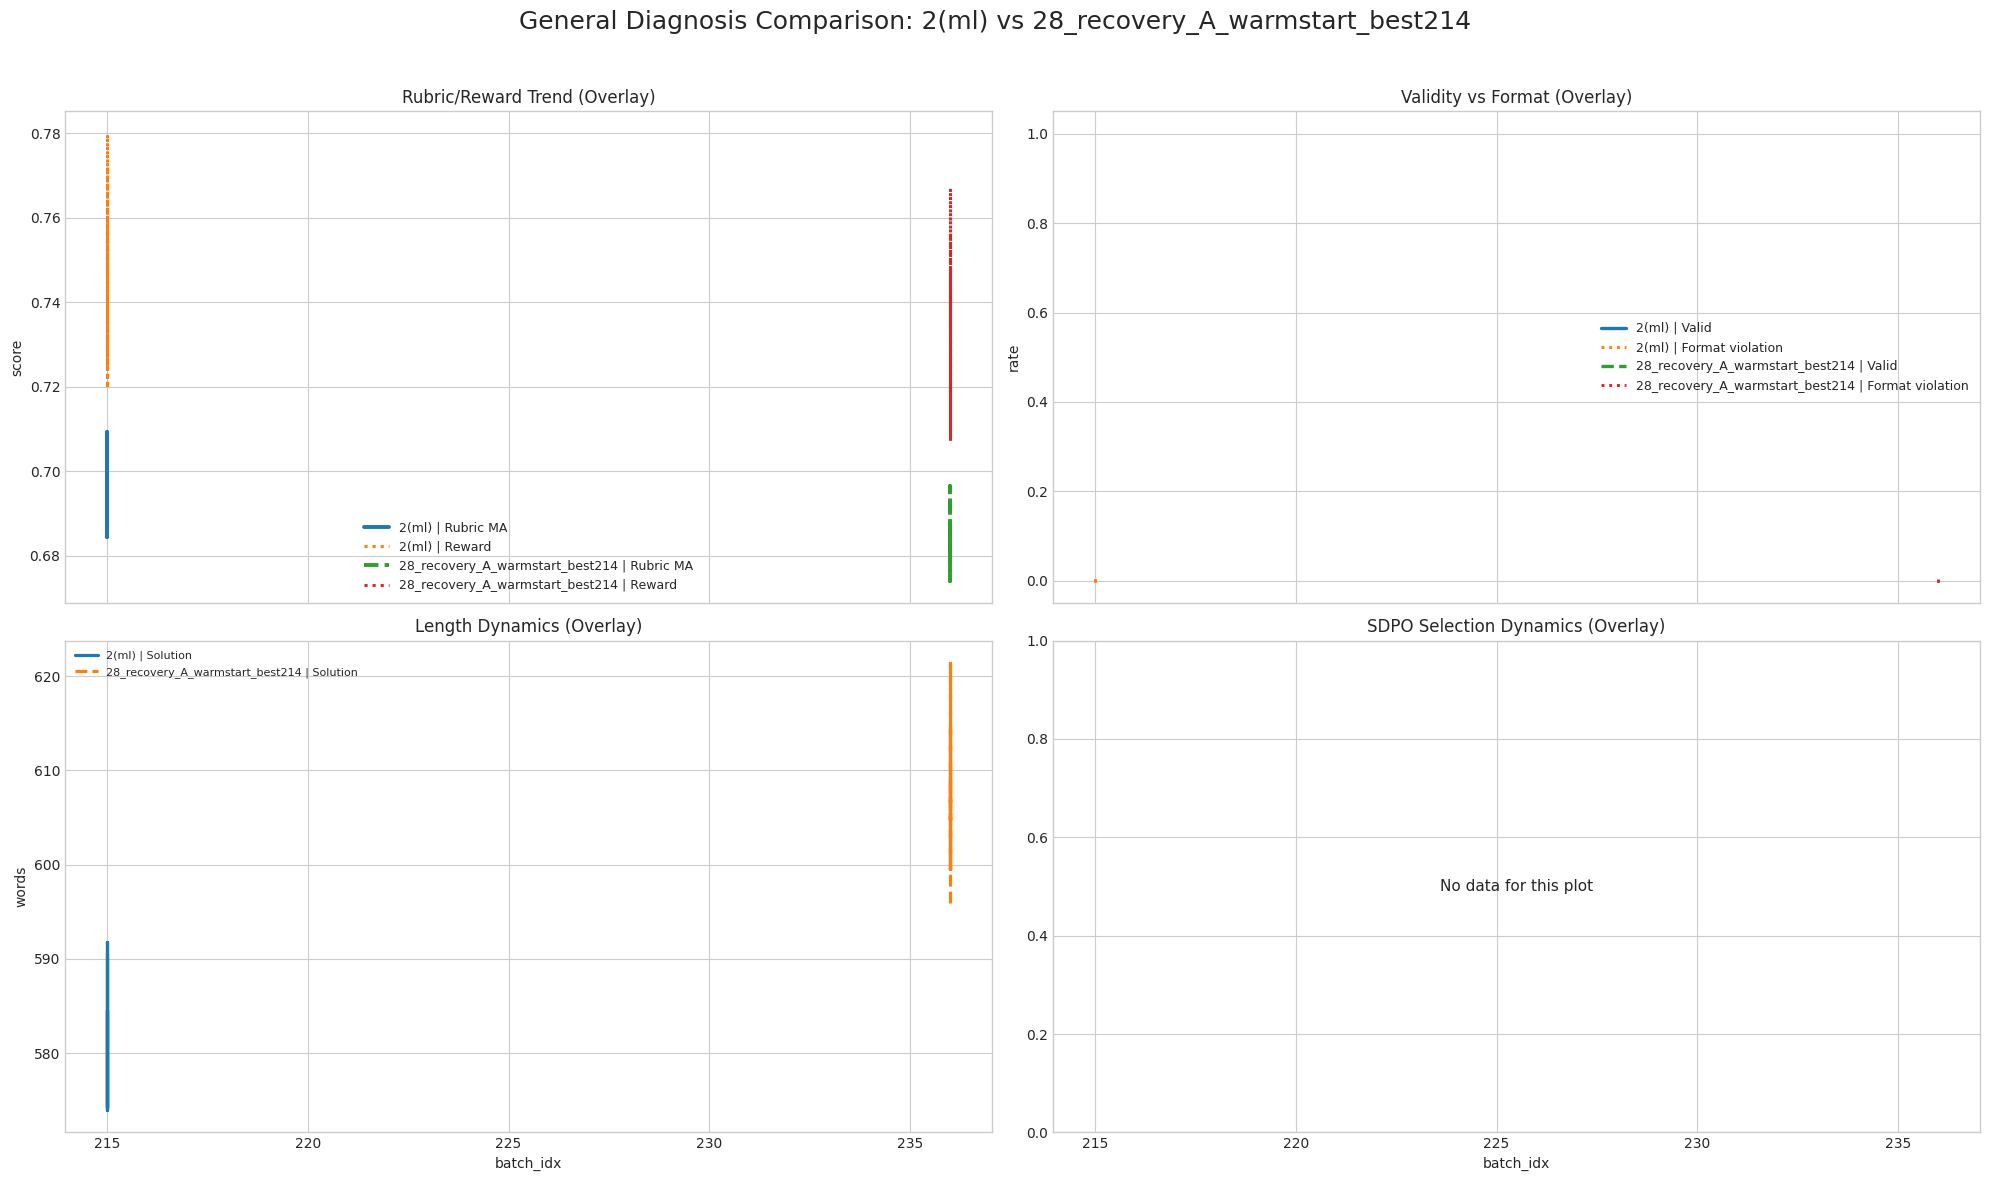

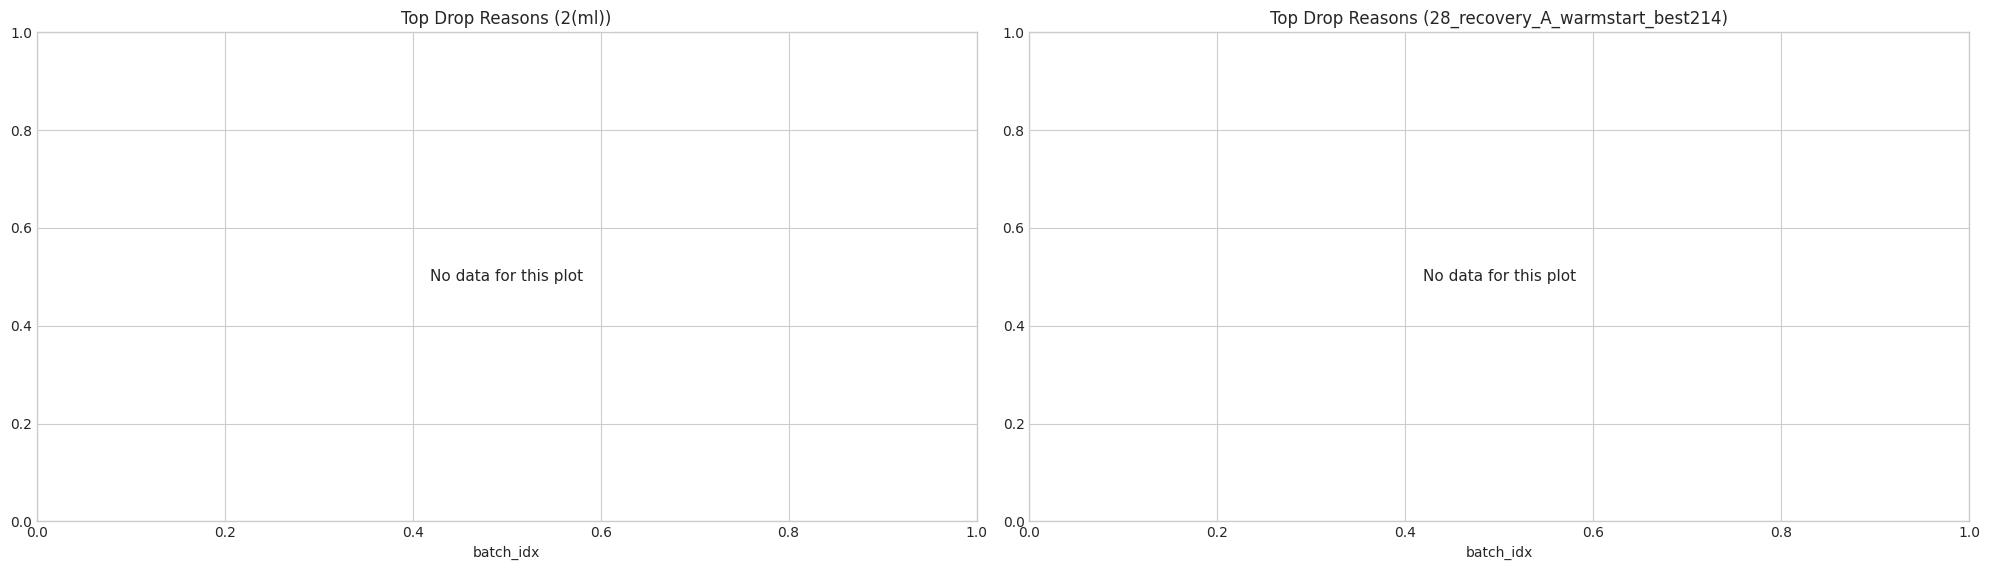

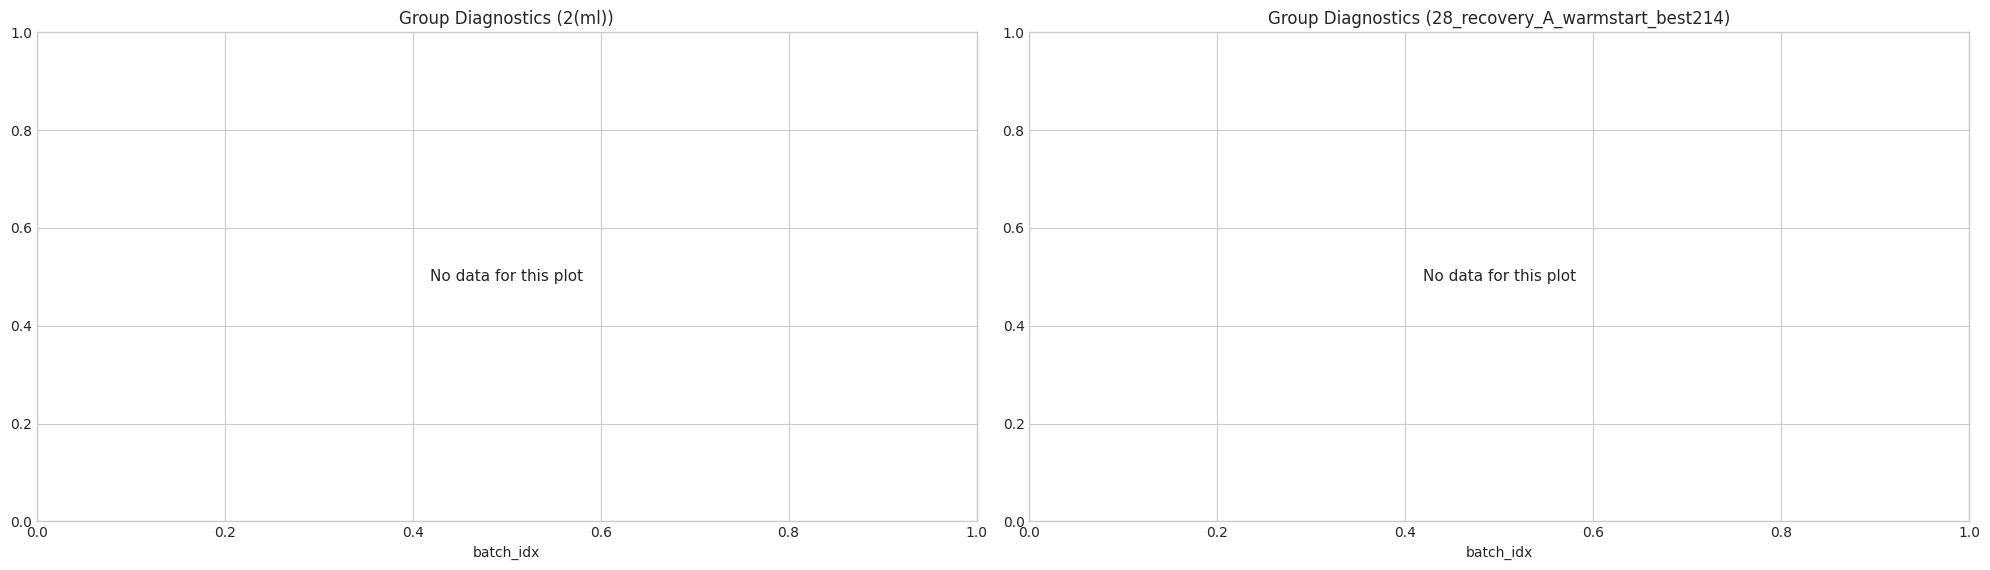

In [13]:
# Plot diagnostics (single-run compact dashboard or two-run comparison layout)
if len(payloads) == 1:
    plot_single_dashboard(payloads[0])
elif len(payloads) == 2:
    plot_two_run_comparison(payloads)
else:
    raise ValueError('Unexpected payload count.')



In [14]:
# Phase summary table (early/middle/late)
phase_tables = []
for pl in payloads:
    t = phase_summary(pl['norm'], pl['label'])
    if not t.empty:
        phase_tables.append(t)

if phase_tables:
    phase_df = pd.concat(phase_tables, axis=0, ignore_index=True)
    display(phase_df.round(4))
else:
    print('No phase summary available.')



,run_label,phase,n_batches,rubric_valid,reward_valid,valid_rate,format_rate,len_solution,len_total,len_think,sdpo_cutoff,sdpo_success_rate
0,2(ml),early,3,0.7022,0.7602,1.0,0.0011,578.8060,NaN,NaN,NaN,NaN
1,2(ml),middle,3,0.6886,0.7437,1.0,0.0019,582.3997,NaN,NaN,NaN,NaN
2,2(ml),late,4,0.6884,0.7467,1.0,0.0011,579.0103,NaN,NaN,NaN,NaN
3,28_recovery_A_warmstart_best214,early,3,0.6958,0.7515,1.0,0.0014,605.6504,NaN,NaN,NaN,NaN
4,28_recovery_A_warmstart_best214,middle,3,0.6738,0.7253,1.0,0.0040,609.4030,NaN,NaN,NaN,NaN
5,28_recovery_A_warmstart_best214,late,4,0.6785,0.7335,1.0,0.0028,605.4795,NaN,NaN,NaN,NaN


## Usage

1. Set one or two entries in `LOG_PATHS` (run directories or direct jsonl files).
2. Toggle `EXAMINE_EVALUATION` as needed.
3. Run all cells top-to-bottom.
4. If a metric is missing in the selected source, its panel will show `No data for this plot`.
5. For quick browsing across `runs/2026/2`, leave `LOG_PATHS=[]` and enable auto-pick settings.
